In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Libraries loaded
TensorFlow version: 2.20.0
GPU available: True


In [ ]:
# Install Prophet
!pip install prophet -qj

print("Prophet installed")

Prophet installed


In [ ]:
# Load the merged dataset
df = pd.read_csv('/content/final_dataset_2022_2024.csv', index_col=0)
df.index = pd.to_datetime(df.index, dayfirst=True)
df = df.sort_index()km

print("Dataset loaded")
print(f"Rows: {df.shape[0]}")
print(f"From: {df.index.min().date()}")
print(f"To:   {df.index.max().date()}")

Dataset loaded
Rows: 52461
From: 2022-01-01
To:   2024-12-31


In [ ]:
# Define the structured feature set
feature_cols = [
    'temp_c', 'wind_speed_kmh', 'humidity_pct',
    'precip_mm', 'wind_chill', 'temp_squared',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'halfhour_slot',
    'event_flag', 'event_intensity',
    'is_public_holiday',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'demand_lag_24h', 'demand_lag_168h',
    'demand_rolling_24h_mean'
]

target = 'demand_mw'

data = df[feature_cols + [target]].dropna()

train = data[data.index.year.isin([2022, 2023])]
test  = data[data.index.year == 2024]

X_train = train[feature_cols]
y_train = train[target]
X_test  = test[feature_cols]
y_test  = test[target]

print(f"Training rows: {len(X_train):,}")
print(f"Test rows:     {len(X_test):,}")

Training rows: 34,617
Test rows:     17,224


In [ ]:
# Train the Random Forest baseline
print("Training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators = 300,
    max_depth    = 10,
    random_state = 42,
    n_jobs       = -1
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_results = pd.DataFrame({
    'actual'     : y_test.values,
    'predicted'  : rf_predictions,
    'event_flag' : test['event_flag'].values,
}, index=test.index)

rf_rmse = np.sqrt(mean_squared_error(rf_results['actual'], rf_results['predicted']))
rf_mae  = mean_absolute_error(rf_results['actual'], rf_results['predicted'])

rf_event    = rf_results[rf_results['event_flag'] == 1]
rf_nonevent = rf_results[rf_results['event_flag'] == 0]
rf_event_rmse    = np.sqrt(mean_squared_error(rf_event['actual'], rf_event['predicted']))
rf_nonevent_rmse = np.sqrt(mean_squared_error(rf_nonevent['actual'], rf_nonevent['predicted']))

print("Random Forest done")
print(f"Overall RMSE: {round(rf_rmse, 2)} MW")
print(f"Overall MAE:  {round(rf_mae, 2)} MW")
print(f"Event RMSE:   {round(rf_event_rmse, 2)} MW")
print(f"Non-Event RMSE: {round(rf_nonevent_rmse, 2)} MW")

Training Random Forest...
Random Forest done
Overall RMSE: 124.86 MW
Overall MAE:  89.86 MW
Event RMSE:   95.33 MW
Non-Event RMSE: 126.52 MW


In [ ]:
# Train the Prophet baseline
print("Training Prophet...")

# Prophet needs columns named ds and y specifically
prophet_train = pd.DataFrame({
    'ds' : train.index,
    'y'  : y_train.values
})

prophet_model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = True,
    seasonality_mode    = 'multiplicative'
)

prophet_model.fit(prophet_train)

# Create future dataframe for 2024
prophet_future = pd.DataFrame({'ds': test.index})
prophet_forecast = prophet_model.predict(prophet_future)

prophet_predictions = prophet_forecast['yhat'].values

prophet_results = pd.DataFrame({
    'actual'     : y_test.values,
    'predicted'  : prophet_predictions,
    'event_flag' : test['event_flag'].values,
}, index=test.index)

prophet_rmse = np.sqrt(mean_squared_error(prophet_results['actual'], prophet_results['predicted']))
prophet_mae  = mean_absolute_error(prophet_results['actual'], prophet_results['predicted'])

p_event    = prophet_results[prophet_results['event_flag'] == 1]
p_nonevent = prophet_results[prophet_results['event_flag'] == 0]
p_event_rmse    = np.sqrt(mean_squared_error(p_event['actual'], p_event['predicted']))
p_nonevent_rmse = np.sqrt(mean_squared_error(p_nonevent['actual'], p_nonevent['predicted']))

print("Prophet done")
print(f"Overall RMSE: {round(prophet_rmse, 2)} MW")
print(f"Overall MAE:  {round(prophet_mae, 2)} MW")
print(f"Event RMSE:   {round(p_event_rmse, 2)} MW")
print(f"Non-Event RMSE: {round(p_nonevent_rmse, 2)} MW")

Training Prophet...
Prophet done
Overall RMSE: 1510.82 MW
Overall MAE:  1365.92 MW
Event RMSE:   1637.37 MW
Non-Event RMSE: 1502.36 MW


In [ ]:
# Define the feature set for the GRU sequence model
gru_feature_cols = [
    'demand_mw',
    'temp_c', 'wind_speed_kmh', 'humidity_pct',
    'precip_mm', 'wind_chill', 'temp_squared',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'halfhour_slot',
    'event_flag', 'event_intensity',
    'is_public_holiday',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos'
]

gru_data = df[gru_feature_cols].dropna()

gru_train = gru_data[gru_data.index.year.isin([2022, 2023])]
gru_test  = gru_data[gru_data.index.year == 2024]

scaler = MinMaxScaler()
gru_train_scaled = scaler.fit_transform(gru_train)
gru_test_scaled  = scaler.transform(gru_test)

print(f"GRU training rows: {len(gru_train_scaled):,}")
print(f"GRU test rows:     {len(gru_test_scaled):,}")
print("Data scaled successfully")

GRU training rows: 35,011
GRU test rows:     17,450
Data scaled successfully


In [ ]:
# Scale features and build 48-step sliding-window sequences
SEQ_LEN = 48

def create_sequences(data, sequence_length=48):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_gru_train, y_gru_train = create_sequences(gru_train_scaled, SEQ_LEN)
X_gru_test,  y_gru_test  = create_sequences(gru_test_scaled,  SEQ_LEN)

print(f"X_gru_train shape: {X_gru_train.shape}")
print(f"X_gru_test shape:  {X_gru_test.shape}")

X_gru_train shape: (34963, 48, 21)
X_gru_test shape:  (17402, 48, 21)


In [ ]:
# Train the GRU model
print("Training GRU...")

gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQ_LEN, X_gru_train.shape[2])),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

gru_history = gru_model.fit(
    X_gru_train, y_gru_train,
    epochs         = 50,
    batch_size     = 64,
    validation_split = 0.1,
    callbacks      = [early_stop],
    verbose        = 1
)

print("GRU training complete")

Training GRU...
Epoch 1/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0073 - val_loss: 0.0023
Epoch 2/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 3/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0017 - val_loss: 7.4979e-04
Epoch 4/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 5/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0010 - val_loss: 4.7553e-04
Epoch 6/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.7515e-04 - val_loss: 4.6704e-04
Epoch 7/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7.6348e-04 - val_loss: 3.3726e-04
Epoch 8/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 7.0418e-04 - val_loss: 3.3756e-04
Epoch 9/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.8654e-04 - val_loss: 2.6483e-04
Epoch 10/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 6.2528e-04 - val_loss: 2.4777e-04
Epoch 11/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.8935e-0

In [ ]:
# Generate GRU predictions and inverse-transform to MW
gru_pred_scaled = gru_model.predict(X_gru_test, verbose=0)

dummy_pred   = np.zeros((len(gru_pred_scaled), len(gru_feature_cols)))
dummy_actual = np.zeros((len(y_gru_test), len(gru_feature_cols)))

dummy_pred[:, 0]   = gru_pred_scaled[:, 0]
dummy_actual[:, 0] = y_gru_test

gru_predictions_mw = scaler.inverse_transform(dummy_pred)[:, 0]
gru_actual_mw      = scaler.inverse_transform(dummy_actual)[:, 0]

gru_test_index = gru_test.index[SEQ_LEN:]

gru_results = pd.DataFrame({
    'actual'     : gru_actual_mw,
    'predicted'  : gru_predictions_mw,
    'event_flag' : gru_test['event_flag'].values[SEQ_LEN:],
}, index=gru_test_index)

gru_rmse = np.sqrt(mean_squared_error(gru_results['actual'], gru_results['predicted']))
gru_mae  = mean_absolute_error(gru_results['actual'], gru_results['predicted'])

gru_event    = gru_results[gru_results['event_flag'] == 1]
gru_nonevent = gru_results[gru_results['event_flag'] == 0]
gru_event_rmse    = np.sqrt(mean_squared_error(gru_event['actual'], gru_event['predicted']))
gru_nonevent_rmse = np.sqrt(mean_squared_error(gru_nonevent['actual'], gru_nonevent['predicted']))

print("GRU done")
print(f"Overall RMSE: {round(gru_rmse, 2)} MW")
print(f"Overall MAE:  {round(gru_mae, 2)} MW")
print(f"Event RMSE:   {round(gru_event_rmse, 2)} MW")
print(f"Non-Event RMSE: {round(gru_nonevent_rmse, 2)} MW")

GRU done
Overall RMSE: 50.44 MW
Overall MAE:  37.78 MW
Event RMSE:   48.12 MW
Non-Event RMSE: 50.59 MW


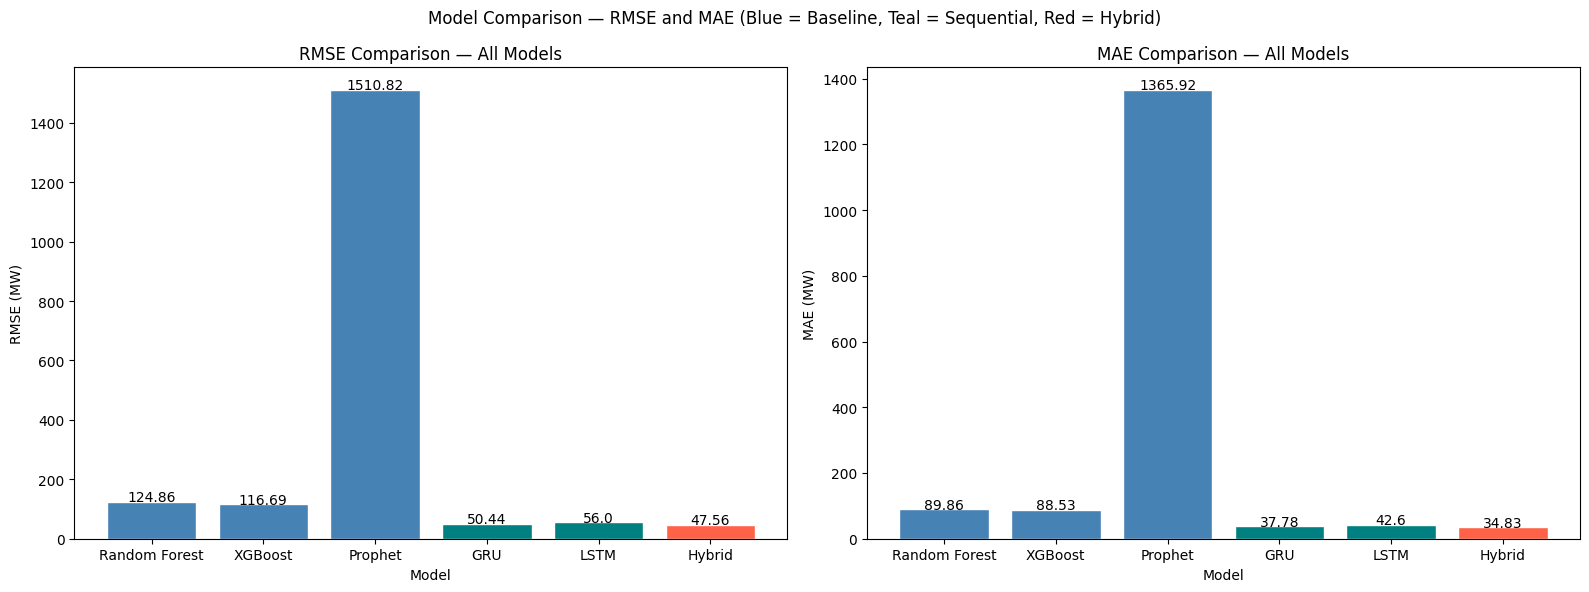

Chart saved


In [ ]:
# Load other models' saved predictions for comparison
baseline = pd.read_csv('/content/baseline_predictions.csv', index_col=0)
baseline.index = pd.to_datetime(baseline.index)
lstm_results = pd.read_csv('/content/lstm_predictions.csv', index_col=0)
lstm_results.index = pd.to_datetime(lstm_results.index)
hybrid_results = pd.read_csv('/content/hybrid_predictions.csv', index_col=0)
hybrid_results.index = pd.to_datetime(hybrid_results.index)

def get_rmse(df):
    return round(np.sqrt(mean_squared_error(df['actual'], df['predicted'])), 2)

def get_mae(df):
    return round(mean_absolute_error(df['actual'], df['predicted']), 2)

models      = ['Random Forest', 'XGBoost', 'Prophet', 'GRU', 'LSTM', 'Hybrid']
rmse_values = [
    get_rmse(rf_results),
    get_rmse(baseline),
    get_rmse(prophet_results),
    get_rmse(gru_results),
    get_rmse(lstm_results),
    get_rmse(hybrid_results)
]
mae_values = [
    get_mae(rf_results),
    get_mae(baseline),
    get_mae(prophet_results),
    get_mae(gru_results),
    get_mae(lstm_results),
    get_mae(hybrid_results)
]

colors = ['steelblue', 'steelblue', 'steelblue', 'teal', 'teal', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(models, rmse_values, color=colors, edgecolor='white')
axes[0].set_title('RMSE Comparison — All Models')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE (MW)')
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

axes[1].bar(models, mae_values, color=colors, edgecolor='white')
axes[1].set_title('MAE Comparison — All Models')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MAE (MW)')
for i, v in enumerate(mae_values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=10)

plt.suptitle('Model Comparison — RMSE and MAE (Blue = Baseline, Teal = Sequential, Red = Hybrid)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/step3b_full_comparison.png', dpi=150)
plt.show()


In [ ]:
# Define helper functions for event/non-event RMSE
def get_event_rmse(df):
    e = df[df['event_flag'] == 1]
    return round(np.sqrt(mean_squared_error(e['actual'], e['predicted'])), 2)

def get_nonevent_rmse(df):
    n = df[df['event_flag'] == 0]
    return round(np.sqrt(mean_squared_error(n['actual'], n['predicted'])), 2)

print("="*75)
print(f"{'Model':<18} {'RMSE':>10} {'MAE':>10} {'Event RMSE':>12} {'Non-Event RMSE':>15}")
print("="*75)

all_results = [
    ('Random Forest', rf_results),
    ('XGBoost',       baseline),
    ('Prophet',       prophet_results),
    ('GRU',          gru_results),
    ('LSTM',         lstm_results),
    ('Hybrid',       hybrid_results),
]

for name, res in all_results:
    print(f"{name:<18} {get_rmse(res):>10} {get_mae(res):>10} {get_event_rmse(res):>12} {get_nonevent_rmse(res):>15}")

print("="*75)
print(f"\nBest model: Hybrid LSTM-XGBoost with RMSE {get_rmse(hybrid_results)} MW")

Model                    RMSE        MAE   Event RMSE  Non-Event RMSE
Random Forest          124.86      89.86        95.33          126.52
XGBoost                116.69      88.53         98.6          117.75
Prophet               1510.82    1365.92      1637.37         1502.36
GRU                     50.44      37.78        48.12           50.59
LSTM                     56.0       42.6         52.2           56.23
Hybrid                  47.56      34.83        41.81           47.91

Best model: Hybrid LSTM-XGBoost with RMSE 47.56 MW


In [ ]:
# Save all model predictions and the GRU modelrf_results.to_csv('/content/rf_predictions.csv')
prophet_results.to_csv('/content/prophet_predictions.csv')
gru_results.to_csv('/content/gru_predictions.csv')
gru_model.save('/content/gru_model.keras')

print("All results saved")
print("rf_predictions.csv")
print("prophet_predictions.csv")
print("gru_predictions.csv")
print("gru_model.keras")
print("step3b_full_comparison.png")
print("Step 3b complete")

All results saved
rf_predictions.csv
prophet_predictions.csv
gru_predictions.csv
gru_model.keras
step3b_full_comparison.png
Step 3b complete
